In [1]:
# Install NLTK if required
!pip install -q nltk

import nltk
import numpy as np
import matplotlib.pyplot as plt

from nltk.corpus import gutenberg
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
nltk.download("gutenberg")

# Load Hamlet
text = gutenberg.raw("shakespeare-hamlet.txt")

print("Dataset loaded successfully.")
print("Total characters:", len(text))

[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Unzipping corpora/gutenberg.zip.


Dataset loaded successfully.
Total characters: 162881


In [3]:
words = text.split()

print("Total number of words:", len(words))

Total number of words: 29605


In [4]:
lines = text.splitlines()

print("First 10 lines of Hamlet:\n")

for i, line in enumerate(lines[:10], start=1):
    print(f"{i}: {line}")

First 10 lines of Hamlet:

1: [The Tragedie of Hamlet by William Shakespeare 1599]
2: 
3: 
4: Actus Primus. Scoena Prima.
5: 
6: Enter Barnardo and Francisco two Centinels.
7: 
8:   Barnardo. Who's there?
9:   Fran. Nay answer me: Stand & vnfold
10: your selfe


In [5]:
text = text.lower()

print(text[:1000])

[the tragedie of hamlet by william shakespeare 1599]


actus primus. scoena prima.

enter barnardo and francisco two centinels.

  barnardo. who's there?
  fran. nay answer me: stand & vnfold
your selfe

   bar. long liue the king

   fran. barnardo?
  bar. he

   fran. you come most carefully vpon your houre

   bar. 'tis now strook twelue, get thee to bed francisco

   fran. for this releefe much thankes: 'tis bitter cold,
and i am sicke at heart

   barn. haue you had quiet guard?
  fran. not a mouse stirring

   barn. well, goodnight. if you do meet horatio and
marcellus, the riuals of my watch, bid them make hast.
enter horatio and marcellus.

  fran. i thinke i heare them. stand: who's there?
  hor. friends to this ground

   mar. and leige-men to the dane

   fran. giue you good night

   mar. o farwel honest soldier, who hath relieu'd you?
  fra. barnardo ha's my place: giue you goodnight.

exit fran.

  mar. holla barnardo

   bar. say, what is horatio there?
  hor. a peece of

In [6]:
import re

# Replace unwanted characters with spaces
text = re.sub(r"[^a-zA-Z0-9.,!?;:'\-\n ]", " ", text)

# Remove extra spaces
text = re.sub(r"\s+", " ", text)

text = text.strip()

print(text[:1000])

the tragedie of hamlet by william shakespeare 1599 actus primus. scoena prima. enter barnardo and francisco two centinels. barnardo. who's there? fran. nay answer me: stand vnfold your selfe bar. long liue the king fran. barnardo? bar. he fran. you come most carefully vpon your houre bar. 'tis now strook twelue, get thee to bed francisco fran. for this releefe much thankes: 'tis bitter cold, and i am sicke at heart barn. haue you had quiet guard? fran. not a mouse stirring barn. well, goodnight. if you do meet horatio and marcellus, the riuals of my watch, bid them make hast. enter horatio and marcellus. fran. i thinke i heare them. stand: who's there? hor. friends to this ground mar. and leige-men to the dane fran. giue you good night mar. o farwel honest soldier, who hath relieu'd you? fra. barnardo ha's my place: giue you goodnight. exit fran. mar. holla barnardo bar. say, what is horatio there? hor. a peece of him bar. welcome horatio, welcome good marcellus mar. what, ha's this th

In [7]:
tokenizer = Tokenizer(
    oov_token="<OOV>"
)

tokenizer.fit_on_texts([text])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary size:", total_words)

Vocabulary size: 4819


In [8]:
word_index = tokenizer.word_index

print("First 20 words in Word Index:\n")

for word, index in list(word_index.items())[:20]:
    print(word, ":", index)

First 20 words in Word Index:

<OOV> : 1
the : 2
and : 3
to : 4
of : 5
i : 6
you : 7
a : 8
my : 9
it : 10
in : 11
that : 12
ham : 13
is : 14
not : 15
his : 16
this : 17
with : 18
your : 19
but : 20


In [9]:
input_sequences = []

# Convert entire text into sentences
sentences = text.split(".")

for sentence in sentences:

    sentence = sentence.strip()

    if len(sentence.split()) < 2:
        continue

    token_list = tokenizer.texts_to_sequences([sentence])[0]

    # Generate n-gram sequences
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

print("Total sequences generated:", len(input_sequences))

Total sequences generated: 27809


In [10]:
print("First 10 numerical sequences:\n")

for seq in input_sequences[:10]:
    print(seq)

First 10 numerical sequences:

[2, 688]
[2, 688, 5]
[2, 688, 5, 46]
[2, 688, 5, 46, 42]
[2, 688, 5, 46, 42, 1887]
[2, 688, 5, 46, 42, 1887, 1888]
[2, 688, 5, 46, 42, 1887, 1888, 1889]
[2, 688, 5, 46, 42, 1887, 1888, 1889, 1181]
[2, 688, 5, 46, 42, 1887, 1888, 1889, 1181, 1890]
[1891, 1892]


In [11]:
index_word = tokenizer.index_word

for seq in input_sequences[:10]:

    words_in_sequence = [
        index_word.get(index, "<UNK>")
        for index in seq
    ]

    print(words_in_sequence)

['the', 'tragedie']
['the', 'tragedie', 'of']
['the', 'tragedie', 'of', 'hamlet']
['the', 'tragedie', 'of', 'hamlet', 'by']
['the', 'tragedie', 'of', 'hamlet', 'by', 'william']
['the', 'tragedie', 'of', 'hamlet', 'by', 'william', 'shakespeare']
['the', 'tragedie', 'of', 'hamlet', 'by', 'william', 'shakespeare', '1599']
['the', 'tragedie', 'of', 'hamlet', 'by', 'william', 'shakespeare', '1599', 'actus']
['the', 'tragedie', 'of', 'hamlet', 'by', 'william', 'shakespeare', '1599', 'actus', 'primus']
['scoena', 'prima']


In [12]:
max_sequence_len = max(
    [len(seq) for seq in input_sequences]
)

print("Maximum sequence length:", max_sequence_len)

Maximum sequence length: 162


In [13]:
input_sequences = np.array(
    pad_sequences(
        input_sequences,
        maxlen=max_sequence_len,
        padding="pre"
    )
)

print("Shape after padding:", input_sequences.shape)

Shape after padding: (27809, 162)


In [14]:
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (27809, 161)
y shape: (27809,)


In [15]:
y = to_categorical(
    y,
    num_classes=total_words
)

print("Encoded y shape:", y.shape)

Encoded y shape: (27809, 4819)


In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dropout, Dense

model = Sequential([
    Input(shape=(max_sequence_len - 1,)),

    Embedding(
        input_dim=total_words,
        output_dim=100
    ),

    LSTM(150, return_sequences=True),

    Dropout(0.2),

    LSTM(100),

    Dropout(0.2),

    Dense(
        total_words,
        activation="softmax"
    )
])

model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 161, 100)       │       481,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 161, 150)       │       150,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 161, 150)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 100)            │       100,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4819)           │       486,719 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,219,619 (4.65 MB)

 Trainable params: 1,219,619 (4.65 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X,
    y,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
186/196 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.0263 - loss: 7.3142

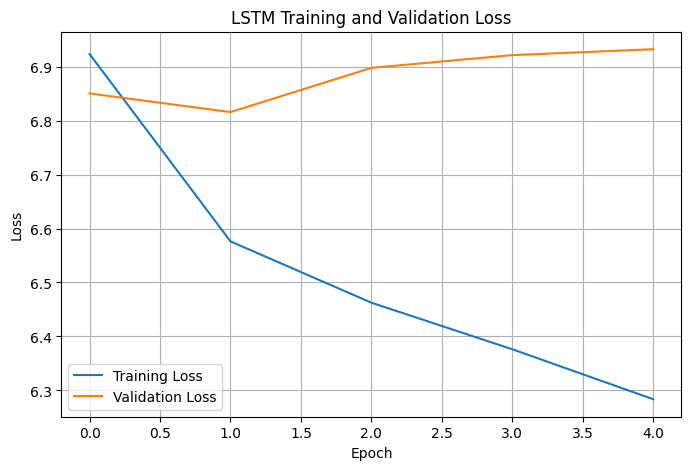

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

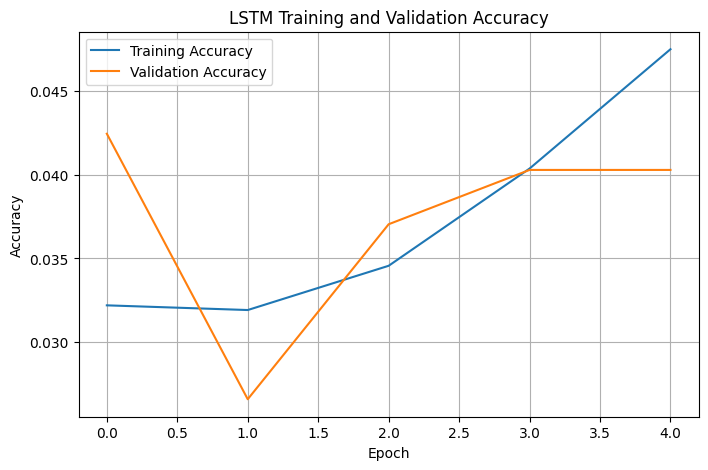

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("LSTM Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [21]:
final_train_loss = history.history["loss"][-1]
final_train_accuracy = history.history["accuracy"][-1]

final_val_loss = history.history["val_loss"][-1]
final_val_accuracy = history.history["val_accuracy"][-1]

print("Final Training Loss:", final_train_loss)
print("Final Training Accuracy:", final_train_accuracy)

print("Final Validation Loss:", final_val_loss)
print("Final Validation Accuracy:", final_val_accuracy)

Final Training Loss: 6.283819675445557
Final Training Accuracy: 0.047466836869716644
Final Validation Loss: 6.932028770446777
Final Validation Accuracy: 0.040273282676935196


In [22]:
def predict_next_word(seed_text):

    # Convert seed text to lowercase
    seed_text = seed_text.lower()

    # Convert text to sequence
    token_list = tokenizer.texts_to_sequences(
        [seed_text]
    )[0]

    # Pad sequence
    token_list = pad_sequences(
        [token_list],
        maxlen=max_sequence_len - 1,
        padding="pre"
    )

    # Predict probabilities
    predicted_probabilities = model.predict(
        token_list,
        verbose=0
    )

    # Select word with highest probability
    predicted_index = np.argmax(
        predicted_probabilities,
        axis=1
    )[0]

    # Convert index to word
    predicted_word = ""

    for word, index in tokenizer.word_index.items():

        if index == predicted_index:
            predicted_word = word
            break

    return predicted_word

In [23]:
test_inputs = [
    "to be or not",
    "the king",
    "what a",
    "good night",
    "my lord"
]

for seed in test_inputs:

    prediction = predict_next_word(seed)

    print(
        f"Input: {seed}"
    )

    print(
        f"Predicted next word: {prediction}"
    )

    print("-" * 50)

Input: to be or not
Predicted next word: the
--------------------------------------------------
Input: the king
Predicted next word: and
--------------------------------------------------
Input: what a
Predicted next word: lord
--------------------------------------------------
Input: good night
Predicted next word: the
--------------------------------------------------
Input: my lord
Predicted next word: and
--------------------------------------------------


In [24]:
def generate_text(seed_text, next_words=5):

    result = seed_text

    for _ in range(next_words):

        next_word = predict_next_word(result)

        if next_word == "":
            break

        result += " " + next_word

    return result

In [25]:
print(
    generate_text(
        "to be or not",
        next_words=5
    )
)

to be or not the lord and the lord


In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dropout, Dense

bi_lstm_model = Sequential([
    Input(shape=(max_sequence_len - 1,)),

    Embedding(
        input_dim=total_words,
        output_dim=100
    ),

    Bidirectional(
        LSTM(128)
    ),

    Dropout(0.2),

    Dense(
        total_words,
        activation="softmax"
    )
])

bi_lstm_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

bi_lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 161, 100)       │       481,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4819)           │     1,238,483 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,954,879 (7.46 MB)

 Trainable params: 1,954,879 (7.46 MB)

 Non-trainable params: 0 (0.00 B)